   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                 

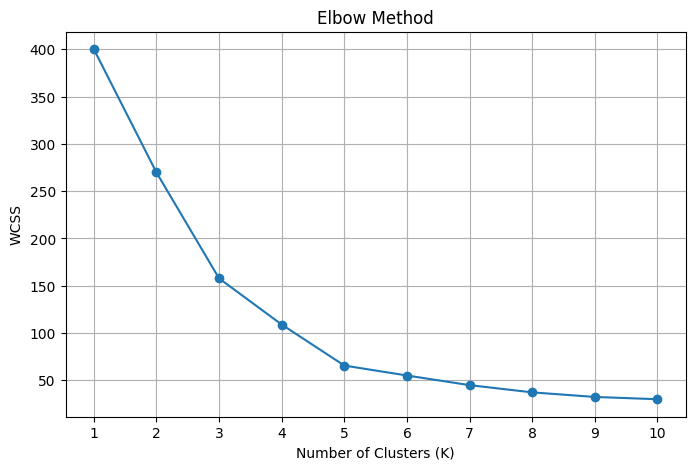

K=2  Silhouette Score = 0.321
K=3  Silhouette Score = 0.467
K=4  Silhouette Score = 0.494
K=5  Silhouette Score = 0.555
K=6  Silhouette Score = 0.540
K=7  Silhouette Score = 0.528
K=8  Silhouette Score = 0.455
K=9  Silhouette Score = 0.457
K=10  Silhouette Score = 0.443


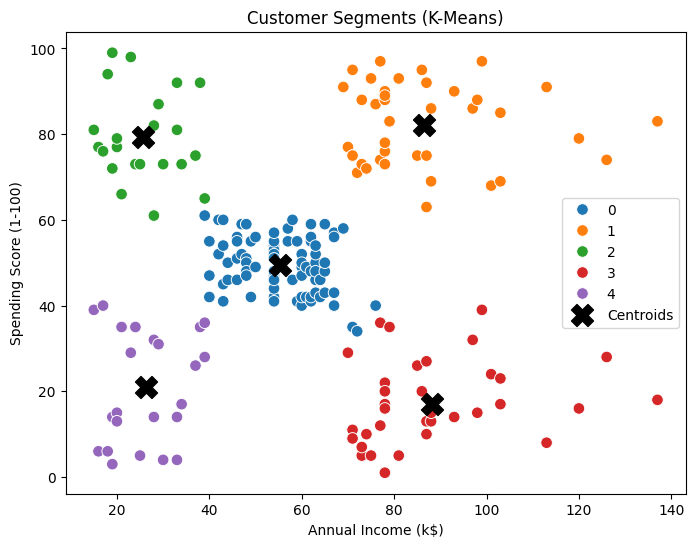

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [1]:
# 1. Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 2. Dataset load kara
df = pd.read_csv("Mall_Customers.csv")
print(df.head())
print(df.info())
print(df.isnull().sum())

# 3. Features nivda (Income ani Spending Score)
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# 4. Scaling (optional pan changli practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Elbow Method - WCSS kadha
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 6. Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker="o", linestyle="-")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# 7. Silhouette score (elbow confirm karayla)
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    print(f"K={k}  Silhouette Score = {silhouette_score(X_scaled, km.labels_):.3f}")

# 8. Elbow varun milalela K vaparun final model (ya dataset sathi K = 5)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# 9. Clusters che visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="tab10",
    s=70
)

# Centroids (original scale madhe parat convert karun)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=250, c="black", marker="X", label="Centroids")

plt.title("Customer Segments (K-Means)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

# 10. Cluster-wise summary
print(df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean())